# Where do the extra rupees in Q1 come from?

**Week 1, Wednesday. Round 2 of 3: the migration's copies and the identity rule.** By the end of
this notebook you can say what makes two records the same order, count the rows that break that
rule, choose which copy to keep, and say what the choice does to Q1 in rupees.

> **The client asks.** "Which Q1 figure is right, and how do you know? My analyst will want to
> see every row you removed."
>
> Anand Iyer, finance controller, Kalpa Retail

> **Kavya's review.** "Tell me what makes two rows the same order before you tell me how many
> duplicates there are. A count of duplicates without an identity rule is a count of nothing."

Round 1 established that the CSV holds 201 rows but only 186 distinct order ids, that one amount
does not convert and sits in the rejects log, and that Q1 over the amounts that convert is
Rs 2,09,98,210. The ERP team's note said the CSV was stitched from two extracts during the Q1
migration. This round finds out what that stitching did.

**Setup.** The same helper and the same two functions as round 1, then round 1's honest pass,
so this notebook starts from 200 accepted rows and a rejects log of one.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

raw = read_orders()
accepted, rejects = [], []
for r in raw:
    value, reason = convert(r["amount"])
    (accepted if value is not None else rejects).append(dict(r, amount=value, reason=reason))
print(len(accepted), "accepted and", len(rejects), "in the rejects log, from", len(raw), "rows")

200 accepted and 1 in the rejects log, from 201 rows


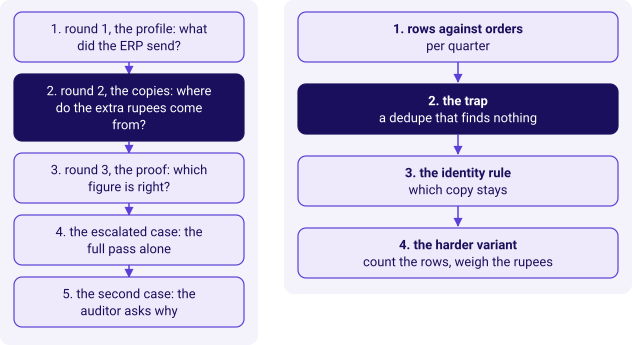

In [2]:
kit.side_by_side(
    kit.ladder(["round 1, the profile: what did the ERP send?", "round 2, the copies: where do the extra rupees come from?",
            "round 3, the proof: which figure is right?", "the escalated case: the full pass alone",
            "the second case: the auditor asks why"], lit=1, show=False),
    kit.vflow(["1. rows against orders\nper quarter",
               "2. the trap\na dedupe that finds nothing",
               "3. the identity rule\nwhich copy stays",
               "4. the harder variant\ncount the rows, weigh the rupees"], lit=1, show=False),
)

## 1. Rows against orders, quarter by quarter

Anand's gap is Rs 20 lakh in Q1. If some orders were exported twice, the rows and the distinct
orders will disagree, and the quarter where they disagree is where the extra rupees sit.

**Predict before you run.** Where do you expect the rows and the distinct order ids to part
company? a) evenly across both quarters; b) mostly in Q1, the quarter of the migration;
c) mostly in Q2, the newer data; d) nowhere, since the difference is one amount.

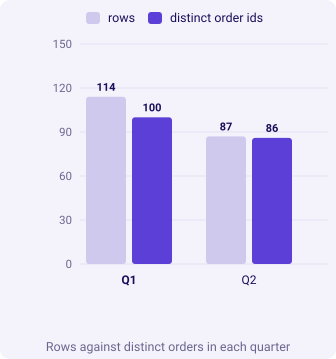

quarter,rows,distinct order ids,rows beyond one per order
Q1,114,100,14
Q2,87,86,1


In [3]:
by_q = {}
for q in ("Q1", "Q2"):
    rows_q = [r for r in raw if r["quarter"] == q]
    by_q[q] = (len(rows_q), len({r["order_id"] for r in rows_q}))
kit.columns(["Q1", "Q2"], [("rows", [by_q["Q1"][0], by_q["Q2"][0]]),
                           ("distinct order ids", [by_q["Q1"][1], by_q["Q2"][1]])],
            lit=(0,), title="Rows against distinct orders in each quarter")
kit.table(["quarter", "rows", "distinct order ids", "rows beyond one per order"],
          [(q, a, b, a - b) for q, (a, b) in by_q.items()])

**What happened.** The answer is b. Q1 holds 114 rows for 100 distinct orders, and Q2 holds 87
rows for 86. Almost all the extra rows sit in Q1, the quarter the migration touched, which is
the quarter where the dashboard and the books disagree. That is a lead, not yet a proof: the
next step is to remove them, and there is a tempting way to do it that removes nothing.

In [4]:
kit.check("Q1 carries 14 rows beyond one per order", by_q["Q1"][0] - by_q["Q1"][1] == 14)
kit.check("Q2 carries 1", by_q["Q2"][0] - by_q["Q2"][1] == 1)

## 2. The trap: a dedupe that reports zero duplicates

**The plausible wrong answer.** Round 1 taught the rejects log to cite a file line, so every
record now carries `line`. The hurried analyst deduplicates on the whole record, the way most
tools do by default, and gets a clean answer.

In [5]:
def whole_record_dedupe(rows):
    seen, kept = set(), []
    for r in rows:
        key = tuple(sorted(r.items()))
        if key not in seen:
            seen.add(key)
            kept.append(r)
    return kept

kept_whole = whole_record_dedupe(accepted)
q1_whole = sum(r["amount"] for r in kept_whole if r["quarter"] == "Q1")
kit.stats([(str(len(accepted) - len(kept_whole)), "duplicates found", "the whole-record dedupe"),
           (kit.rupees(q1_whole), "Q1 revenue", "unchanged, so the dashboard looks right"),
           ("Rs 20 lakh", "left unexplained", "and the note says Finance is wrong")],
          caption="The hurried dedupe, as it would be reported")

**Why it is wrong.** The file line is where a row sat in the export, not what the order is. Two
copies of one order sit on different lines, so every record is unique by construction and the
dedupe can never find anything. The note would tell Anand there are no duplicates and his books
are Rs 20 lakh short, which sends Finance hunting for revenue that was never earned. The check
that catches it is the one round 1 already printed: 201 rows and 186 distinct order ids cannot
both be true of a file with zero duplicates.

The mechanism, on five invented records: two orders appear twice.

In [6]:
# Invented records, to show the mechanism without touching the ERP file.
invented = [
    {"order_id": "INV-01", "segment": "Retail-Plus", "order_date": "2026-05-03", "amount": "2400"},
    {"order_id": "INV-02", "segment": "Retail-Core", "order_date": "2026-05-09", "amount": "1300"},
    {"order_id": "INV-01", "segment": "Retail-Plus", "order_date": "2026-05-03", "amount": "2400"},
    {"order_id": "INV-03", "segment": "Business", "order_date": "2026-06-11", "amount": "450000"},
    {"order_id": "INV-03", "segment": "Business", "order_date": "2026-06-11", "amount": "450000"},
]
for n, r in enumerate(invented, start=2):
    r["line"] = n

found = len(invented) - len(whole_record_dedupe(invented))
without_line = [{k: v for k, v in r.items() if k != "line"} for r in invented]
found_without = len(without_line) - len(whole_record_dedupe(without_line))
kit.table(["the comparison", "duplicates found in the invented five"],
          [("every field, including the file line", found),
           ("every field except the file line", found_without),
           ("the order id alone", len(invented) - len({r["order_id"] for r in invented}))],
          caption="Invented records: the file line makes every row unique")

the comparison,duplicates found in the invented five
"every field, including the file line",0
every field except the file line,2
the order id alone,2


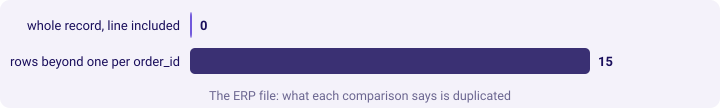

In [7]:
ids = [r["order_id"] for r in raw]
kit.check("the whole-record dedupe reports zero on the ERP file", len(accepted) - len(kept_whole) == 0)
kit.check("yet distinct order ids fall 15 short of the rows", len(ids) - len(set(ids)) == 15,
          f"{len(ids)} rows, {len(set(ids))} ids")
kit.check("on invented records, dropping the line field finds both copies", found == 0 and found_without == 2)
kit.bars([("whole record, line included", len(accepted) - len(kept_whole)),
          ("rows beyond one per order_id", len(ids) - len(set(ids)))], lit=(1,),
         title="The ERP file: what each comparison says is duplicated")

## 3. The identity rule, and which copy stays

**The fix.** Say what makes two records the same order before counting anything: here it is
`order_id`, because the ERP issues one id per order and never reuses it. Group the rows by that
key. A group of one is an order; a group of two is one order exported twice, and one row of the
pair has to be chosen.

The choice is not always free. On invented records again: pair A is an exact copy; in pair B,
one copy's amount does not convert and the other's does; in pair C, the two copies disagree on
the date and agree on everything else.

**Predict before you run.** For pair B, which copy should stay? a) the first, since the first
extract is the original; b) the one whose amount converts, since the other cannot be summed;
c) both, until Finance decides; d) neither, since a pair that disagrees cannot be trusted.

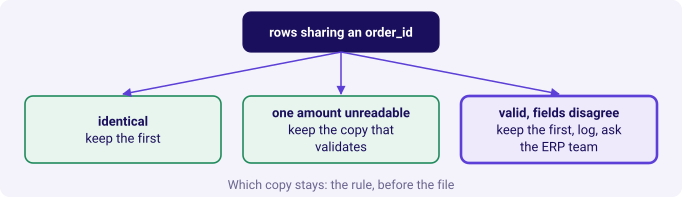

order,kept line,kept amount,set aside,reason
INV-11,12,1800,90,second copy of the order
INV-12,95,2600,20,copy whose amount does not convert; its twin carries the value
INV-13,40,3100,99,"second copy of the order, differs on order_date"


In [8]:
pairs = [
    {"order_id": "INV-11", "order_date": "2026-05-02", "amount": "1800", "line": 12},
    {"order_id": "INV-11", "order_date": "2026-05-02", "amount": "1800", "line": 90},
    {"order_id": "INV-12", "order_date": "2026-05-14", "amount": "n/a", "line": 20},
    {"order_id": "INV-12", "order_date": "2026-05-14", "amount": "2600", "line": 95},
    {"order_id": "INV-13", "order_date": "2026-08-21", "amount": "3100", "line": 40},
    {"order_id": "INV-13", "order_date": "2026-07-30", "amount": "3100", "line": 99},
]

def identity_rule(rows):
    """Keep one row per order_id: the first copy whose amount converts; log the rest with a reason."""
    kept, log = {}, []
    for r in rows:
        value, _ = convert(r["amount"])
        k = r["order_id"]
        if k not in kept:
            kept[k] = r
            continue
        first_ok = convert(kept[k]["amount"])[0] is not None
        if not first_ok and value is not None:
            log.append((kept[k], "copy whose amount does not convert; its twin carries the value"))
            kept[k] = r
        else:
            differs = [f for f in r if f != "line" and r[f] != kept[k].get(f)]
            log.append((r, "second copy of the order" + (f", differs on {', '.join(differs)}" if differs else "")))
    return list(kept.values()), log

kept_pairs, log_pairs = identity_rule(pairs)
kit.tree({"label": "rows sharing an order_id", "kind": "lit", "branches": [
    ("", {"label": "identical\nkeep the first", "kind": "good"}),
    ("", {"label": "one amount unreadable\nkeep the copy that validates", "kind": "good"}),
    ("", {"label": "valid, fields disagree\nkeep the first, log, ask the ERP team", "kind": "known"})]},
    title="Which copy stays: the rule, before the file")
kit.table(["order", "kept line", "kept amount", "set aside", "reason"],
          [(k["order_id"], k["line"], k["amount"], r["line"], why)
           for k in kept_pairs for r, why in log_pairs if r["order_id"] == k["order_id"]],
          caption="Invented pairs: one row per order, and a reason for every row set aside")

**What happened.** The answer is b. Keeping the first copy of pair B would keep the one that
cannot be summed and throw away the one that carries the order's value, so the rule prefers the
copy whose fields validate. Pair C is subtler: both copies are valid, they disagree on the date,
and no rule inside the file can say which date is true. The rule keeps the first extract's row,
logs the disagreement, and the date becomes a question for the ERP team, written down rather
than guessed.

Now the same rule on the ERP file, starting again from the raw rows so the rejected amount can
find its twin.

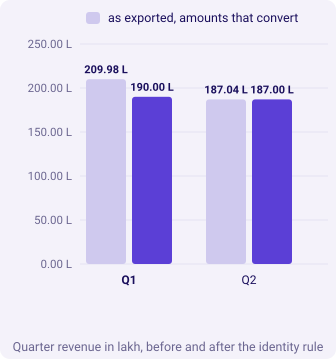

In [9]:
clean, dup_log = identity_rule(raw)
clean = [dict(r, amount=convert(r["amount"])[0]) for r in clean]
q = {x: sum(r["amount"] for r in clean if r["quarter"] == x) for x in ("Q1", "Q2")}
q_raw = {x: sum(r["amount"] for r in accepted if r["quarter"] == x) for x in ("Q1", "Q2")}
kit.columns(["Q1", "Q2"], [("as exported, amounts that convert", [q_raw["Q1"] / 1e5, q_raw["Q2"] / 1e5]),
                           ("one row per order", [q["Q1"] / 1e5, q["Q2"] / 1e5])],
            fmt=lambda v: f"{v:,.2f} L", lit=(0,), title="Quarter revenue in lakh, before and after the identity rule")
kit.stats([(str(len(clean)), "orders kept", "one row per order_id"),
           (str(len(dup_log)), "rows set aside", "each with a reason in the log"),
           (kit.rupees(q["Q1"]), "Q1", "Anand's books say 1.9 crore"),
           (kit.rupees(q["Q2"]), "Q2", "one row per order")])

**Your turn.** The log holds a reason for every row set aside. In the empty cell below, print the
rows whose reason says the copies differ, with `[(r["line"], r["order_id"], why) for r, why in
dup_log if "differs" in why or "twin" in why]`. For each, write which field disagreed and what you
would ask the ERP team.

In [10]:
kit.check("186 orders kept and 15 rows set aside", (len(clean), len(dup_log)) == (186, 15))
kit.check("every kept order has an amount that converts", all(isinstance(r["amount"], int) for r in clean))
kit.check("Q1 lands on Rs 1,90,00,000", q["Q1"] == 19000000, kit.rupees(q["Q1"]))
kit.check("kept plus set aside is every row", len(clean) + len(dup_log) == len(raw))

**What changed.** Q1 moved from Rs 2,09,98,210 as exported to Rs 1,90,00,000 with one row per
order, which is Finance's 1.9 crore. Fifteen rows were set aside, fourteen of them in Q1, and the
one amount round 1 could not read turned out to be a copy whose twin carries the order's value,
so no revenue was lost with it.

> **Kavya's review.** "Good: an identity rule, a preference for the copy that validates, and a
> reason on every row you set aside. Now show me the rupees each group of rows carried, because
> fifteen rows is not one kind of problem."

## 4. The harder variant: count the rows, weigh the rupees

Fifteen rows sounds like one problem. The rupees say otherwise, and the note to Anand has to
say which rows carried his Rs 20 lakh, since that is what his analyst will check first.

**Predict before you run.** Of the Rs 19,98,210 the identity rule removed from Q1, what share did
the Business rows carry? a) about a sixth, since they are 2 of 14 rows; b) about half;
c) nearly all of it, since a Business order runs to lakhs; d) none, since Business orders
are never duplicated.

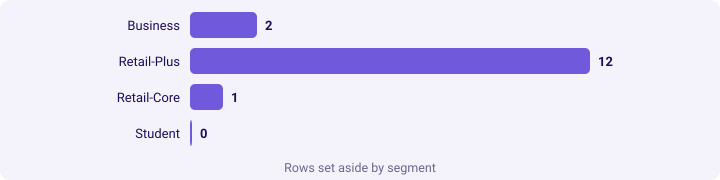

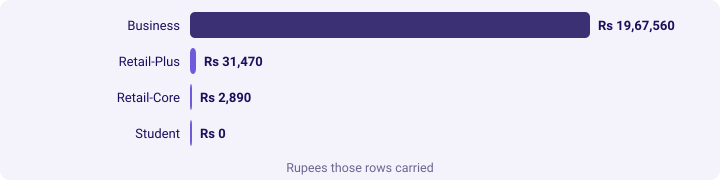

In [11]:
removed = [r for r, why in dup_log]
segs = ["Business", "Retail-Plus", "Retail-Core", "Student"]
rows_removed = [sum(1 for r in removed if r["segment"] == s) for s in segs]
rupees_removed = [sum(convert(r["amount"])[0] or 0 for r in removed if r["segment"] == s) for s in segs]
kit.bars(list(zip(segs, rows_removed)), title="Rows set aside by segment")
kit.bars(list(zip(segs, rupees_removed)), fmt=kit.rupees, lit=(0,), title="Rupees those rows carried")

**What happened.** The answer is c. Two Business rows carry Rs 19,67,560 of the Rs 19,98,210,
about 98 percent, while the membership tier carries most of the rows and a sliver of the rupees.
That split decides two different conversations. Anand's gap is explained by two corporate orders
counted twice. Tuesday's finding is a different matter: the extra rows sit mostly in Retail-Plus
in Q1, which is the segment and the quarter Tuesday compared, so its orders-per-customer fall
was measured on inflated Q1 counts. Round 3 recomputes it.

In [12]:
share = rupees_removed[0] / sum(rupees_removed)
kit.check("the Business rows carry over 95 percent of the rupees removed", share > 0.95, f"{share:.1%}")
kit.check("Retail-Plus carries the most rows set aside", rows_removed[1] == max(rows_removed),
          f"{rows_removed[1]} of {len(removed)}")

### In the interview

**[F] How do you find duplicates, and what makes two records the same?** "I start with the
identity rule, not the tool. I ask what the business says makes two records one thing: for an
order that is the order id the system issues; for a customer it might be a normalised email or a
phone number, and for a payment the gateway's reference. Then I count rows against distinct keys.
A whole-record comparison only finds exact copies, and a copy made in a migration often differs
somewhere, a timestamp, a load id, a line number. For each group I keep one row by a stated
preference, usually the copy whose fields validate, and I log every row I set aside with its
reason. Then I weigh them: two rows can carry more money than a hundred."

**[F] A dedupe returns zero duplicates. Do you believe it?** "Only after I check it against a
count of distinct keys. If rows and distinct keys disagree, the dedupe compared on something
that makes every row unique, such as a load timestamp, a surrogate key or a line number."

### Depth: when the identity rule is not one field

Kalpa's order id is issued by one system, so one field is the identity. A customer arriving from
two systems is harder: the same person as `anand.iyer@kalpa` and `Anand.Iyer@Kalpa ` differ as text.
That is record linkage, and it starts the same way, by writing down what makes two records one
before counting anything. Week 2 meets duplicate keys again, in a join, where they multiply rows
instead of adding them.

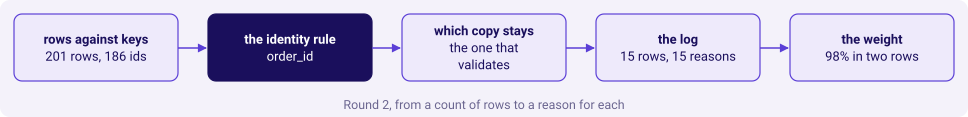

What round 2 established,The number
"Orders kept, one row per order_id",186
"Rows set aside, each with a reason","15, of which 14 in Q1"
Q1 with one row per order,"Rs 1,90,00,000"
Q2 with one row per order,"Rs 1,87,00,000"
Share of removed Q1 rupees in Business rows,98%


In [13]:
kit.flow(["rows against keys\n201 rows, 186 ids", "the identity rule\norder_id",
          "which copy stays\nthe one that validates", "the log\n15 rows, 15 reasons",
          "the weight\n98% in two rows"], lit=1,
         title="Round 2, from a count of rows to a reason for each")
kit.table(["What round 2 established", "The number"],
          [("Orders kept, one row per order_id", "186"),
           ("Rows set aside, each with a reason", "15, of which 14 in Q1"),
           ("Q1 with one row per order", kit.rupees(q["Q1"])),
           ("Q2 with one row per order", kit.rupees(q["Q2"])),
           ("Share of removed Q1 rupees in Business rows", f"{share:.0%}")])

In [14]:
kit.check_summary()
print("Next: round 3 decides what else stays, proves the reconciliation to the rupee, and recomputes Tuesday.")

Next: round 3 decides what else stays, proves the reconciliation to the rupee, and recomputes Tuesday.
